# 08 - Conditional VAE

Notebook para entrenar el `ConditionalVAE` usando el mismo flujo que el AutoEncoder/VAE: dataset, validacion, scheduler, early stopping, guardado del mejor modelo y log de resultados.


In [1]:
%run init_notebook.py

import os
import time
from pathlib import Path

import torch
import torch.nn.functional as F
import torch.optim as optim
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from tqdm import tqdm

from config import DATA_PATH, LOGS_PATH
from src.dataset import NSynth, nsynth_collate_fn
from src.losses import MultiDecoderLoss
from src.models2 import ConditionalVAE
from src.utils.logger import save_training_results

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

MODEL_DIR = DATA_PATH / 'models'
CHECKPOINT_DIR = MODEL_DIR / 'checkpoints'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
LOGS_PATH.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / 'cvae.pth'
#model_path = r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae.pth"
print('Modelo:', model_path)


Device: cuda
GPU: NVIDIA GeForce RTX 3090
Modelo: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae.pth


In [2]:
# Hiperparametros de audio / Mel
SAMPLE_RATE = 16000
N_FFT = 1024
HOP_LENGTH = 160
N_MELS = 80
MAX_FRAMES = 128
INPUT_SIZE = (N_MELS, MAX_FRAMES)

# Hiperparametros de entrenamiento
EPOCHS = 50
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
PATIENCE_ES = 5
NUM_WORKERS = 0  # en Windows/Jupyter suele ser mas estable que 2+
PIN_MEMORY = DEVICE.type == 'cuda'
RESUME = True
SAVE_EVERY = 5
GRAD_CLIP_NORM = 5.0

# Hiperparametros del modelo
LATENT_DIM = 256
CHANNELS = [1, 32, 64, 128, 256]
CONDITION_DIM = 128
N_HARMONICS = 64
DDSP_HIDDEN = 256

# Hiperparametros de la loss
BETA_MAX = 0.1
BETA_WARMUP_EPOCHS = 5
LAMBDA_MEL = 1.0
LAMBDA_DDSP = 1.0

mel_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    power=2.0,
).to(DEVICE)


def waveforms_to_mel(waveforms):
    """Convierte waveform [B,1,T] a log-Mel [B,1,N_MELS,MAX_FRAMES]."""
    mel = mel_transform(waveforms)
    mel = torch.log1p(mel)

    if mel.shape[-1] > MAX_FRAMES:
        mel = mel[..., :MAX_FRAMES]
    elif mel.shape[-1] < MAX_FRAMES:
        mel = F.pad(mel, (0, MAX_FRAMES - mel.shape[-1]))

    return mel


def stack_feature(value, device):
    """Collate robusto por si algun .pt tiene distinta longitud de frames."""
    if torch.is_tensor(value):
        return value.float().to(device, non_blocking=True)

    max_len = max(v.shape[-1] for v in value)
    padded = []
    for v in value:
        v = v.float()
        if v.shape[-1] < max_len:
            v = F.pad(v, (0, max_len - v.shape[-1]))
        else:
            v = v[..., :max_len]
        padded.append(v)
    return torch.stack(padded).to(device, non_blocking=True)


def conditions_to_device(conditions, device):
    return {
        'instrument_onehot': conditions['instrument_onehot'].float().to(device, non_blocking=True),
        'pitch_norm': conditions['pitch_norm'].float().to(device, non_blocking=True),
        'velocity_norm': conditions['velocity_norm'].float().to(device, non_blocking=True),
        'brightness': conditions['brightness'].float().to(device, non_blocking=True),
        'sustain': conditions['sustain'].float().to(device, non_blocking=True),
    }


In [3]:
# Features extraidas por Extract_features.py. Para validacion usa una carpeta propia si existe.
FEATURES_ROOT = DATA_PATH / 'nsynth_features'
TRAIN_FEATURES_DIR = FEATURES_ROOT / 'train'
VALID_FEATURES_DIR = FEATURES_ROOT / 'validation'


def build_nsynth_dataset(partition, features_dir):
    ds = NSynth(
        partition=partition,
        features_dir=str(features_dir),
        require_features=True,
    )
    return ds

print('Cargando training...')
train_dataset = build_nsynth_dataset('training', TRAIN_FEATURES_DIR)

valid_dataset = None
if VALID_FEATURES_DIR.exists():
    print('Cargando validation...')
    valid_dataset = build_nsynth_dataset('validation', VALID_FEATURES_DIR)
    if len(valid_dataset) == 0:
        print('Validation no tiene .pt compatibles; se entrenara sin validacion.')
        valid_dataset = None
else:
    print(f'No existe {VALID_FEATURES_DIR}; se entrenara sin validacion.')

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=nsynth_collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

valid_loader = None
if valid_dataset is not None:
    valid_loader = DataLoader(
        valid_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=nsynth_collate_fn,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

print('Train samples:', len(train_dataset))
print('Valid samples:', 0 if valid_dataset is None else len(valid_dataset))
print('Train batches:', len(train_loader))


Cargando training...
Carga completada: 289205 muestras de todos los instrumentos.
No existe C:\Users\Articuno\Desktop\TFG-MUSICAL\data\nsynth_features\validation; se entrenara sin validacion.
Train samples: 289205
Valid samples: 0
Train batches: 18076


In [4]:
model = ConditionalVAE(
    input_size=INPUT_SIZE,
    latent_dim=LATENT_DIM,
    channels=CHANNELS,
    condition_dim=CONDITION_DIM,
    n_frames=MAX_FRAMES,
    n_harmonics=N_HARMONICS,
    ddsp_hidden=DDSP_HIDDEN,
).to(DEVICE)

if RESUME and model_path.exists():
    state = torch.load(model_path, map_location=DEVICE)
    model.load_state_dict(state)
    print('Modelo cargado desde checkpoint existente.')
else:
    print('Entrenando desde cero.')

beta_steps = max(1, len(train_loader) * BETA_WARMUP_EPOCHS)
loss_fn = MultiDecoderLoss(
    beta_max=BETA_MAX,
    beta_steps=beta_steps,
    lambda_mel=LAMBDA_MEL,
    lambda_ddsp=LAMBDA_DDSP,
).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametros entrenables: {n_params:,}')
print(f'Beta warmup steps: {beta_steps}')


Modelo cargado desde checkpoint existente.
Parametros entrenables: 12,306,049
Beta warmup steps: 90380


In [5]:
# Smoke test de shapes antes de lanzar el entrenamiento completo.
batch = next(iter(train_loader))
waveforms, srs, keys, metadatas, features, conditions = batch
waveforms = waveforms.to(DEVICE, non_blocking=True)
mel_orig = waveforms_to_mel(waveforms)
cond = conditions_to_device(conditions, DEVICE)

with torch.no_grad():
    mel_hat, ddsp_params, kld = model(
        mel_orig,
        cond['instrument_onehot'],
        cond['pitch_norm'],
        cond['velocity_norm'],
        cond['brightness'],
        cond['sustain'],
    )

print('mel_orig:', tuple(mel_orig.shape))
print('mel_hat :', tuple(mel_hat.shape))
print('f0      :', tuple(ddsp_params['f0_scale'].shape))
print('loudness:', tuple(ddsp_params['loudness_scale'].shape))
print('harm    :', tuple(ddsp_params['harmonics'].shape))
print('kld     :', tuple(kld.shape))


c:\Users\Articuno\Desktop\TFG-MUSICAL\env-musical-serious-business\Lib\site-packages\torch\_utils.py:831: UserWarning:

TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()



mel_orig: (16, 1, 80, 128)
mel_hat : (16, 1, 80, 128)
f0      : (16, 128)
loudness: (16, 128)
harm    : (16, 128, 64)
kld     : (16,)


In [6]:
def run_epoch(loader, train=True):
    model.train(train)
    totals = {
        'total': 0.0,
        'mel': 0.0,
        'ddsp': 0.0,
        'f0': 0.0,
        'loudness': 0.0,
        'kld': 0.0,
        'beta': 0.0,
    }
    n_seen = 0

    desc = 'train' if train else 'valid'
    iterator = tqdm(loader, desc=desc, leave=False)
    context = torch.enable_grad() if train else torch.no_grad()

    with context:
        for batch in iterator:
            waveforms, srs, keys, metadatas, features, conditions = batch
            waveforms = waveforms.to(DEVICE, non_blocking=True)
            mel_orig = waveforms_to_mel(waveforms)

            cond = conditions_to_device(conditions, DEVICE)
            features_real = {
                'f0': stack_feature(features['f0'], DEVICE),
                'loudness_db': stack_feature(features['loudness_db'], DEVICE),
            }

            if train:
                optimizer.zero_grad(set_to_none=True)

            mel_hat, ddsp_params, kld = model(
                mel_orig,
                cond['instrument_onehot'],
                cond['pitch_norm'],
                cond['velocity_norm'],
                cond['brightness'],
                cond['sustain'],
            )
            loss, loss_dict = loss_fn(mel_orig, mel_hat, ddsp_params, features_real, kld)

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                optimizer.step()
                loss_fn.step_beta()

            batch_size = waveforms.shape[0]
            n_seen += batch_size
            totals['total'] += loss.item() * batch_size
            for key in ['mel', 'ddsp', 'f0', 'loudness', 'kld', 'beta']:
                totals[key] += float(loss_dict[key]) * batch_size

            iterator.set_postfix(
                loss=f'{loss.item():.4f}',
                mel=f"{loss_dict['mel']:.4f}",
                ddsp=f"{loss_dict['ddsp']:.4f}",
                beta=f"{loss_dict['beta']:.4f}",
            )

    return {key: value / max(1, n_seen) for key, value in totals.items()}


history = {
    'train_total': [], 'train_mel': [], 'train_ddsp': [], 'train_f0': [],
    'train_loudness': [], 'train_kld': [], 'train_beta': [],
    'valid_total': [], 'valid_mel': [], 'valid_ddsp': [], 'valid_f0': [],
    'valid_loudness': [], 'valid_kld': [], 'valid_beta': [],
}

best_metric = float('inf')
epochs_no_improve = 0
total_epoch_time = 0.0

print('Starting training on', DEVICE)
for epoch in range(1, EPOCHS + 1):
    start = time.time()

    train_stats = run_epoch(train_loader, train=True)
    for key, value in train_stats.items():
        history[f'train_{key}'].append(value)

    if valid_loader is not None:
        valid_stats = run_epoch(valid_loader, train=False)
        for key, value in valid_stats.items():
            history[f'valid_{key}'].append(value)
        metric = valid_stats['total']
    else:
        valid_stats = None
        metric = train_stats['total']

    scheduler.step(metric)

    epoch_time = time.time() - start
    total_epoch_time += epoch_time

    if valid_stats is None:
        print(
            f"Epoch {epoch:03d} | "
            f"train={train_stats['total']:.4f} "
            f"mel={train_stats['mel']:.4f} ddsp={train_stats['ddsp']:.4f} "
            f"kld={train_stats['kld']:.4f} beta={train_stats['beta']:.4f} "
            f"time={epoch_time:.1f}s"
        )
    else:
        print(
            f"Epoch {epoch:03d} | "
            f"train={train_stats['total']:.4f} valid={valid_stats['total']:.4f} "
            f"mel={valid_stats['mel']:.4f} ddsp={valid_stats['ddsp']:.4f} "
            f"kld={valid_stats['kld']:.4f} beta={train_stats['beta']:.4f} "
            f"time={epoch_time:.1f}s"
        )

    if metric < best_metric:
        best_metric = metric
        epochs_no_improve = 0
        torch.save(model.state_dict(), model_path)
        print(f'  Mejor modelo guardado en: {model_path}')
    else:
        epochs_no_improve += 1

    if epoch % SAVE_EVERY == 0:
        epoch_ckpt = CHECKPOINT_DIR / f'cvae_epoch_{epoch:03d}.pth'
        torch.save(model.state_dict(), epoch_ckpt)
        print(f'  Checkpoint guardado en: {epoch_ckpt}')

    if epochs_no_improve >= PATIENCE_ES:
        print(f'Early stopping en epoch {epoch}.')
        break

print('Training complete.')


Starting training on cuda


Epoch 001 | train=0.4608 mel=0.4003 ddsp=0.0321 kld=3.6989 beta=0.0100 time=3844.8s
  Mejor modelo guardado en: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae.pth


Epoch 002 | train=0.4992 mel=0.4204 ddsp=0.0345 kld=1.5192 beta=0.0300 time=2466.6s


Epoch 003 | train=0.5206 mel=0.4333 ddsp=0.0370 kld=1.0175 beta=0.0500 time=759.4s


Epoch 004 | train=0.5367 mel=0.4428 ddsp=0.0398 kld=0.7774 beta=0.0700 time=752.1s


Epoch 005 | train=0.5489 mel=0.4511 ddsp=0.0420 kld=0.6212 beta=0.0900 time=761.5s
  Checkpoint guardado en: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\checkpoints\cvae_epoch_005.pth


Epoch 006 | train=0.5471 mel=0.4492 ddsp=0.0421 kld=0.5586 beta=0.1000 time=762.3s
Early stopping en epoch 6.
Training complete.


In [7]:
results = {
    'train_total': history['train_total'],
    'train_mel': history['train_mel'],
    'train_ddsp': history['train_ddsp'],
    'train_f0': history['train_f0'],
    'train_loudness': history['train_loudness'],
    'train_kld': history['train_kld'],
    'train_beta': history['train_beta'],
    'valid_total': history['valid_total'],
    'valid_mel': history['valid_mel'],
    'valid_ddsp': history['valid_ddsp'],
    'valid_f0': history['valid_f0'],
    'valid_loudness': history['valid_loudness'],
    'valid_kld': history['valid_kld'],
    'valid_beta': history['valid_beta'],
    'num_epochs': len(history['train_total']),
    'avg_epoch_time': total_epoch_time / max(1, len(history['train_total'])),
    'best_metric': best_metric,
    'model_path': str(model_path),
    'learning_rate': LEARNING_RATE,
    'batch_size': BATCH_SIZE,
    'sample_rate': SAMPLE_RATE,
    'n_fft': N_FFT,
    'hop_length': HOP_LENGTH,
    'n_mels': N_MELS,
    'max_frames': MAX_FRAMES,
    'input_size': INPUT_SIZE,
    'latent_dim': LATENT_DIM,
    'channels': CHANNELS,
    'condition_dim': CONDITION_DIM,
    'n_harmonics': N_HARMONICS,
    'beta_max': BETA_MAX,
    'beta_warmup_epochs': BETA_WARMUP_EPOCHS,
    'lambda_mel': LAMBDA_MEL,
    'lambda_ddsp': LAMBDA_DDSP,
}

save_training_results(results, 'cvae.json')
print('Resultados guardados en:', LOGS_PATH / 'cvae.json')
print('Mejor modelo:', model_path)


Resultados guardados en: C:\Users\Articuno\Desktop\TFG-MUSICAL\logs\cvae.json
Mejor modelo: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae.pth


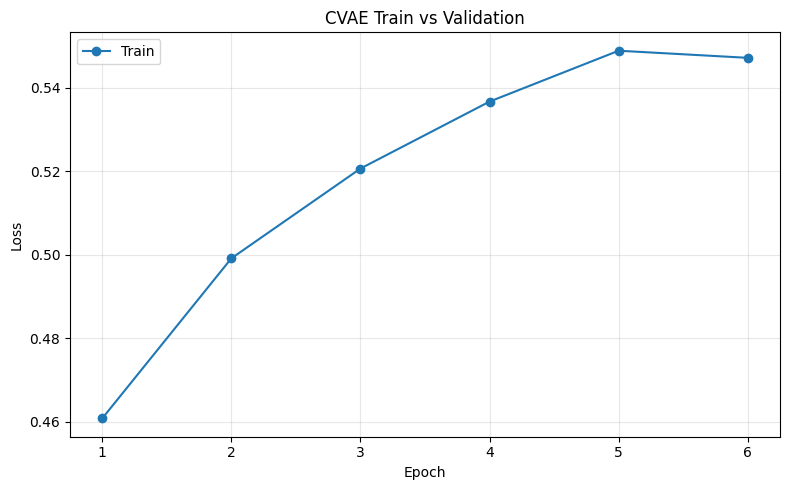

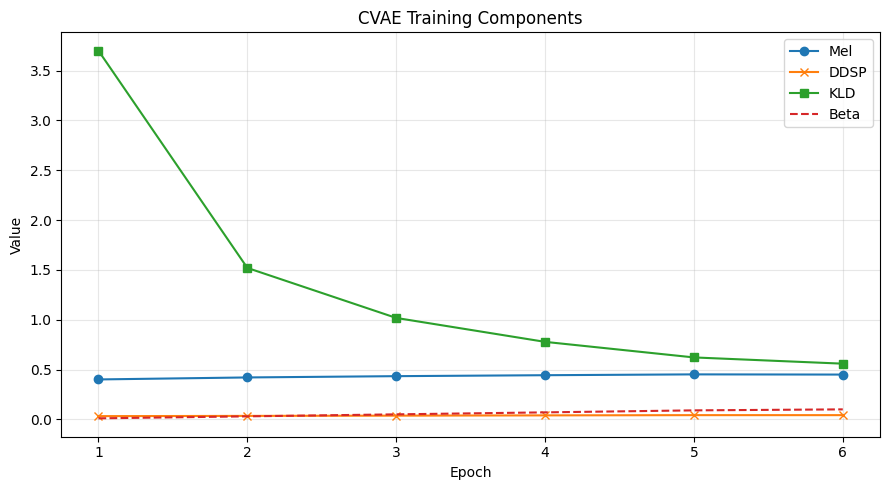

In [8]:
epochs = range(1, len(history['train_total']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history['train_total'], label='Train', marker='o')
if history['valid_total']:
    plt.plot(epochs, history['valid_total'], label='Validation', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CVAE Train vs Validation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(epochs, history['train_mel'], label='Mel', marker='o')
plt.plot(epochs, history['train_ddsp'], label='DDSP', marker='x')
plt.plot(epochs, history['train_kld'], label='KLD', marker='s')
plt.plot(epochs, history['train_beta'], label='Beta', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('CVAE Training Components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
